# GEMs Project - Prep for 06/22/26 Lab Meeting

```
Continuing work from: 
~/2026_GEMs/stm_model_test/0608_0619.ipynb
```

## Purpose
For lab meeting I want to show two experiments: 

1. Gene knockout analysis
2. Oxygen Variable Concentrations

### Experimental Design

| **Sample** | **iMAT Threshold** | **Model Name** |
|:---|---|:---|
| 278 | 10%-80%-10% | mixed_stm1090_model |
| 278 | 15%-70%-15% | mixed_stm1585_model |
| 278 | 25%-50%-25% | mixed_stm2575_model |
| 279 | 10%-80%-10% | stm1090_model |
| 279 | 15%-70%-15% | stm1585_model |
| 279 | 25%-50%-25% | stm2575_model |
|STM_V1_0 | None | control_model |


#### Medium Conditions
Infection Conditions

Uninfected Conditions (?)

Control 

Do I make variable changes of the infection and uninfected mediums??

### Results
- Growth rate of each model in each condition with each gene knockout.
    - There's some more specifics involved here. I should reference the notebooks I used when I did my comittee meeting and first lab presentation. 
- Growth rate of each model in each condition with different oxygen levels plotted.

## Saturday Plan
**Goal:** Get the full workflow of the (1) medium conditions, (2) gene knockout study, and (3) oxygen variability study. Quality of the data, interprebility, thorough analysis, and accuracy of the medium conditions are all secondary. Just get the experiments working and putting out something. 

## Sunday Plan
**Goal:** Throw the ugly data on some slides. Prepare the presentation talk outline. Go back and regenerate any experimental data that does not make sense in order of worst to best. 

## Generate Models
### Prepare the Gene Weights

In [1]:
# Set the gurobi solver 

import os
from cobra.core.configuration import Configuration

os.environ["GRB_LICENSE_FILE"] = "/Users/gina/.gurobi.lic"
Configuration().solver = "gurobi"

In [2]:
# Read in the gene weights CSV files

import pandas as pd

stm_threshold_10_90 = pd.read_csv("../imat_prep_test/stm_threshold_10_90.csv")
stm_threshold_15_85 = pd.read_csv("../imat_prep_test/stm_threshold_15_85.csv")
stm_threshold_25_75 = pd.read_csv("../imat_prep_test/stm_threshold_25_75.csv")

mixed_stm_threshold_10_90 = pd.read_csv("../imat_prep_test/mixed_stm_threshold_10_90.csv")
mixed_stm_threshold_15_85 = pd.read_csv("../imat_prep_test/mixed_stm_threshold_15_85.csv")
mixed_stm_threshold_25_75 = pd.read_csv("../imat_prep_test/mixed_stm_threshold_25_75.csv")

In [3]:
# Make a python set of each gene weights CSV
stm_set_10_90 = set(stm_threshold_10_90["genes"].astype(str).str.strip())
stm_set_15_85 = set(stm_threshold_15_85["genes"].astype(str).str.strip())
stm_set_25_75 = set(stm_threshold_25_75["genes"].astype(str).str.strip())

mixed_stm_set_10_90 = set(mixed_stm_threshold_10_90["genes"].astype(str).str.strip())
mixed_stm_set_15_85 = set(mixed_stm_threshold_15_85["genes"].astype(str).str.strip())
mixed_stm_set_25_75 = set(mixed_stm_threshold_25_75["genes"].astype(str).str.strip())

# QC: Check the count of genes
print("STM1090 gene count",len(stm_set_10_90), "|", "STM1585 gene count", len(stm_set_15_85), "|", "STM2575 gene count", len(stm_set_25_75))
print("Mixed STM1090 gene count",len(mixed_stm_set_10_90), "|", "Mixed STM1585 gene count", len(mixed_stm_set_15_85), "|", "Mixed STM2575 gene count", len(mixed_stm_set_25_75))

STM1090 gene count 4671 | STM1585 gene count 4671 | STM2575 gene count 4671
Mixed STM1090 gene count 4671 | Mixed STM1585 gene count 4671 | Mixed STM2575 gene count 4671


In [4]:
# Load STM_V1_0

from cobra.io import load_model, load_json_model

control_model = load_model("STM_v1_0")

/Users/gina/miniforge3/envs/localgems/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2789960
Academic license 2789960 - for non-commercial use only - registered to gm___@ucdavis.edu


In [5]:
# Save all genes in the control model in a set

model_genes = set([g.id for g in control_model.genes])

# QC: Check the count of genes
print("STM_V1_0 Control Model has", len(model_genes), "total genes")

STM_V1_0 Control Model has 1271 total genes


In [6]:
# Subset the gene weights lists for each sample to keep only the genes also found in the control model

stm1090_model = stm_threshold_10_90[stm_threshold_10_90["genes"].isin(model_genes)]
stm1585_model = stm_threshold_15_85[stm_threshold_15_85["genes"].isin(model_genes)]
stm2575_model = stm_threshold_25_75[stm_threshold_25_75["genes"].isin(model_genes)]

mixed_stm1090_model = mixed_stm_threshold_10_90[mixed_stm_threshold_10_90["genes"].isin(model_genes)]
mixed_stm1585_model = mixed_stm_threshold_15_85[mixed_stm_threshold_15_85["genes"].isin(model_genes)]
mixed_stm2575_model = mixed_stm_threshold_25_75[mixed_stm_threshold_25_75["genes"].isin(model_genes)]

In [7]:
# Align the gene weights lists to the control model genes list and assign missing genes a weight of 0

subset_weights_stm1090 = stm1090_model.set_index("genes")["threshold_category"].reindex(model_genes, fill_value=0)
subset_weights_stm1585 = stm1585_model.set_index("genes")["threshold_category"].reindex(model_genes, fill_value=0)
subset_weights_stm2575 = stm2575_model.set_index("genes")["threshold_category"].reindex(model_genes, fill_value=0)

subset_weights_mixedstm1090 = mixed_stm1090_model.set_index("genes")["threshold_category"].reindex(model_genes, fill_value=0)
subset_weights_mixedstm1585 = mixed_stm1585_model.set_index("genes")["threshold_category"].reindex(model_genes, fill_value=0)
subset_weights_mixedstm2575 = mixed_stm2575_model.set_index("genes")["threshold_category"].reindex(model_genes, fill_value=0)


# QC: Confirm all samples have the same amount of gene weights

# 1. Make a list of the subset gene weights
subset_gene_weights = [
    subset_weights_stm1090,
    subset_weights_stm1585,
    subset_weights_stm2575,
    subset_weights_mixedstm1090,
    subset_weights_mixedstm1090,
    subset_weights_mixedstm2575]

# 2. Make a list of how many genes are in each list
gene_counts = [len(weights) for weights in subset_gene_weights]

# 3. Compare how many genes are in each list and print the total if they are all the same
if len(set(gene_counts)) == 1:
    print(f"All models have {gene_counts[0]} genes")
else:
    print("Gene counts differ between models")
    print(gene_counts)

All models have 1271 genes


### Convert Gene Weights to Reaction Weights

In [8]:
# Convert gene weights to reaction weights with iMAT

from imatpy.parse_gpr import gene_to_rxn_weights

rxn_weights_stm1090 = gene_to_rxn_weights(control_model, subset_weights_stm1090)
rxn_weights_stm1585 = gene_to_rxn_weights(control_model, subset_weights_stm1585)
rxn_weights_stm2575 = gene_to_rxn_weights(control_model, subset_weights_stm2575)

rxn_weights_mixedstm1090 = gene_to_rxn_weights(control_model, subset_weights_mixedstm1090)
rxn_weights_mixedstm1585 = gene_to_rxn_weights(control_model, subset_weights_mixedstm1585)
rxn_weights_mixedstm2575 = gene_to_rxn_weights(control_model, subset_weights_mixedstm2575)

# QC: Confirm all samples have the same amount of reaction weights

# 1. Make a list of the reaction weights
reaction_weights = [
    rxn_weights_stm1090,
    rxn_weights_stm1585,
    rxn_weights_stm2575,
    rxn_weights_mixedstm1090,
    rxn_weights_mixedstm1585,
    rxn_weights_mixedstm2575]

# 2. Make a list of how many genes are in each list
reactions_counts = [len(weights) for weights in reaction_weights]

# 3. Compare how many genes are in each list and print the total if they are all the same
if len(set(reactions_counts)) == 1:
    print(f"All models have {reactions_counts[0]} reactions")
else:
    print("Reaction counts differ between models")
    print(reactions_counts)

All models have 2545 reactions


### Generate Constrained Models with iMAT

In [9]:
# Generate constrained models with iMAT by integrating the reaction weights

from imatpy.model_creation import generate_model

stm1090_model = generate_model(model = control_model, rxn_weights = rxn_weights_stm1090, method = "imat_restrictions")
stm1585_model = generate_model(model = control_model, rxn_weights = rxn_weights_stm1585, method = "imat_restrictions")
stm2575_model = generate_model(model = control_model, rxn_weights = rxn_weights_stm2575, method = "imat_restrictions")

mixedstm1090_model = generate_model(model = control_model, rxn_weights = rxn_weights_mixedstm1090, method = "imat_restrictions")
mixedstm1585_model = generate_model(model = control_model, rxn_weights = rxn_weights_mixedstm1585, method = "imat_restrictions")
mixedstm2575_model = generate_model(model = control_model, rxn_weights = rxn_weights_mixedstm2575, method = "imat_restrictions")

         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/bd/zvg2hfl13hs5_kdz07q5mm700000gn/T/tmprf5z4oqw.lp
Reading time = 0.01 seconds
: 1802 rows, 5090 columns, 19612 nonzeros
         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/bd/zvg2hfl13hs5_kdz07q5mm700000gn/T/tmpwvbt6ac5.lp
Reading time = 0.01 seconds
: 1802 rows, 5090 columns, 19612 nonzeros
         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/bd/zvg2hfl13hs5_kdz07q5mm700000gn/T/tmp0s6o_1j2.lp
Reading time = 0.01 seconds
: 1802 rows, 5090 columns, 19612 nonzeros
         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/bd/zvg2hfl13hs5_kdz07q5mm700000gn/T/tmp2fjkm8zb.lp
Reading time = 0.01 seconds
: 1802 rows, 5090 columns, 19612 nonzeros
         of a constant term in the left-hand side of a constraint.



## Design Experimental Medium Conditions

### Default Medium

**Coding Question**

How does the for loop "know" what rxn_id and uptake_value? For example, if I wrote this for loop 
```
for rxn_id in control_model.medium: 
    rxn = control_model.reactions.get_by_id(rxn_id) 
    met = list(rxn.metabolites)[0] 
    print(rxn_id, "|", met.id, "|", met.name)
```
How would it know that I am referencing the reaction and not the uptake value? 

In [52]:
# List the default medium exchange reactions, metabolites, and uptake value

for rxn_id, uptake_value in control_model.medium.items():
    rxn = control_model.reactions.get_by_id(rxn_id)
    met = list(rxn.metabolites)[0]
    print(rxn_id, "|", met.id, "|", met.name, "|", uptake_value)

EX_ca2_e | ca2_e | Calcium | 1000.0
EX_cbl1_e | cbl1_e | Cob(I)alamin | 0.01
EX_cl_e | cl_e | Chloride | 1000.0
EX_co2_e | co2_e | CO2 CO2 | 1000.0
EX_cobalt2_e | cobalt2_e | Co2+ | 1000.0
EX_cu2_e | cu2_e | Copper | 1000.0
EX_mg2_e | mg2_e | Magnesium | 1000.0
EX_fe2_e | fe2_e | Fe2+ mitochondria | 1000.0
EX_fe3_e | fe3_e | Iron (Fe3+) | 1000.0
EX_mn2_e | mn2_e | Manganese | 1000.0
EX_mobd_e | mobd_e | Molybdate | 1000.0
EX_na1_e | na1_e | Sodium | 1000.0
EX_nh4_e | nh4_e | Ammonium | 1000.0
EX_o2_e | o2_e | O2 O2 | 18.5
EX_pi_e | pi_e | Phosphate | 1000.0
EX_zn2_e | zn2_e | Zinc | 1000.0
EX_so4_e | so4_e | Sulfate | 1000.0
EX_glc__D_e | glc__D_e | D-Glucose | 5.0
EX_tungs_e | tungs_e | Tungstate | 1000.0
EX_h2o_e | h2o_e | H2O H2O | 100.0
EX_h_e | h_e | H+ | 100.0
EX_k_e | k_e | Potassium | 1000.0


In [55]:
# Create a default_medium dictionary

default_medium = {
 'EX_ca2_e': 1000.0,
 'EX_cbl1_e': 0.01,
 'EX_cl_e': 1000.0,
 'EX_co2_e': 1000.0,
 'EX_cobalt2_e': 1000.0,
 'EX_cu2_e': 1000.0,
 'EX_mg2_e': 1000.0,
 'EX_fe2_e': 1000.0,
 'EX_fe3_e': 1000.0,
 'EX_mn2_e': 1000.0,
 'EX_mobd_e': 1000.0,
 'EX_na1_e': 1000.0,
 'EX_nh4_e': 1000.0,
 'EX_o2_e': 18.5,
 'EX_pi_e': 1000.0,
 'EX_zn2_e': 1000.0,
 'EX_so4_e': 1000.0,
 'EX_glc__D_e': 5.0,
 'EX_tungs_e': 1000.0,
 'EX_h2o_e': 100.0,
 'EX_h_e': 100.0,
 'EX_k_e': 1000.0}

### Infected Mice Medium

In [56]:
# Make an infection condition medium dictionary with metabolites from SW's list and include the default medium conditions.

infected_medium = dict(default_medium)
infected_medium.update({
    "EX_o2_e": 9.0,
    "EX_tet_e": 4.0,
    "EX_no3_e": 0.5,
    "EX_etha_e": 1.0,
    "EX_12ppd__R_e": 0.1,
    "EX_12ppd__S_e": 0.1,
    "EX_lac__L_e": 10.0,
    "EX_for_e": 4.0,
    "EX_succ_e": 3.0,
    "EX_asp__L_e": 5.0,
    "EX_mal__L_e": 0.2,
    "EX_galct__D_e": 10.0,
    "EX_glcr_e": 10.0,
    "EX_pyr_e": 10.0,
    "EX_arab__L_e": 13.3,
    "EX_but_e": 10.0,
    "EX_ac_e": 50.0,
    "EX_ppa_e": 5.0,
    "EX_glc__D_e": 0.0, # eliminate the glucose present in the default medium
})

### Uninfected Mice Medium

In [65]:
# Make a non-infection condition medium dictionary with metabolites from SW's list and include the default medium conditions.

uninfected_medium = dict(default_medium)
uninfected_medium.update({
    "EX_o2_e": 9.0,
    "EX_tet_e": 0.05,
    "EX_no3_e": 0.05,
    "EX_etha_e": 1.0,
    "EX_12ppd__R_e": 0.1,
    "EX_12ppd__S_e": 0.1,
    "EX_lac__L_e": 10.0,
    "EX_for_e": 4.0,
    "EX_succ_e": 3.0,
    "EX_asp__L_e": 5.0,
    "EX_mal__L_e": 0.2,
    "EX_galct__D_e": 10.0,
    "EX_glcr_e": 10.0,
    "EX_pyr_e": 10.0,
    "EX_arab__L_e": 13.3,
    "EX_but_e": 10.0,
    "EX_ac_e": 50.0,
    "EX_ppa_e": 5.0,
    "EX_glc__D_e": 0.0, # eliminate the glucose present in the default medium
})

### Oxygen availability Gradient Medium(s)

In [58]:
# Store the default, infected and uninfected medias in one dictionary
base_media = {
    "default": default_medium,
    "infected": infected_medium,
    "uninfected": uninfected_medium,
}

In [15]:
# Make an oxygen gradient from 0 to 18.5 by 0.1 increments

import numpy as np

oxygen_levels = np.round(np.arange(0, 18.5 + 0.1, 0.1), 1)

In [59]:
# Make a function that takes the one medium dictionary, copies it, changes the oxygen value, and returns the modified medium

def make_o2_medium(base_medium, o2_value, o2_rxn="EX_o2_e"):
    """
    Return a copy of a medium dictionary with oxygen set to a new value.
    All other medium components stay the same.
    """
    new_medium = base_medium.copy()
    new_medium[o2_rxn] = float(o2_value)
    return new_medium


**Coding Question:**

I don't understand the nested dictionary. I also don't undertand how the `condition_name` is known. The final structure of oxygen_gradient_media looks like this: 

```
oxygen_gradient_media = {
    "default": {
        0.0: default medium with oxygen 0.0,
        0.1: default medium with oxygen 0.1,
        ...
        18.5: default medium with oxygen 18.5,
    },

    "infected": {
        0.0: infected medium with oxygen 0.0,
        0.1: infected medium with oxygen 0.1,
        ...
        18.5: infected medium with oxygen 18.5,
    },

    "uninfected": {
        0.0: uninfected medium with oxygen 0.0,
        0.1: uninfected medium with oxygen 0.1,
        ...
        18.5: uninfected medium with oxygen 18.5,
    }
}
```

It might be easier for me to understand this alternative: 
```
oxygen_gradient_media = {}

for condition_name, base_medium in base_media.items():

    oxygen_gradient_media[condition_name] = {}

    for o2 in oxygen_levels:

        oxygen_gradient_media[condition_name][o2] = make_o2_medium(base_medium, o2)
```



In [17]:
# Make oxygen-gradient media for each condition

oxygen_gradient_media = {
    condition_name: {
        o2: make_o2_medium(base_medium, o2)
        for o2 in oxygen_levels
    }
    for condition_name, base_medium in base_media.items()
}

In [60]:
# QC: See the infected medium with a value of 5 for the oxygen reaction

oxygen_gradient_media["infected"][5]

{'EX_ca2_e': 1000.0,
 'EX_cbl1_e': 0.01,
 'EX_cl_e': 1000.0,
 'EX_co2_e': 1000.0,
 'EX_cobalt2_e': 1000.0,
 'EX_cu2_e': 1000.0,
 'EX_mg2_e': 1000.0,
 'EX_fe2_e': 1000.0,
 'EX_fe3_e': 1000.0,
 'EX_mn2_e': 1000.0,
 'EX_mobd_e': 1000.0,
 'EX_na1_e': 1000.0,
 'EX_nh4_e': 1000.0,
 'EX_o2_e': 5.0,
 'EX_pi_e': 1000.0,
 'EX_zn2_e': 1000.0,
 'EX_so4_e': 1000.0,
 'EX_glc__D_e': 0.0,
 'EX_tungs_e': 1000.0,
 'EX_h2o_e': 100.0,
 'EX_h_e': 100.0,
 'EX_k_e': 1000.0,
 'EX_tet_e': 4.0,
 'EX_no3_e': 0.5,
 'EX_etha_e': 1.0,
 'EX_12ppd__R_e': 0.1,
 'EX_12ppd__S_e': 0.1,
 'EX_lac__L_e': 10.0,
 'EX_for_e': 4.0,
 'EX_succ_e': 3.0,
 'EX_asp__L_e': 5.0,
 'EX_mal__L_e': 0.2,
 'EX_galct__D_e': 10.0,
 'EX_glcr_e': 10.0,
 'EX_pyr_e': 10.0,
 'EX_arab__L_e': 13.3,
 'EX_but_e': 10.0,
 'EX_ac_e': 50.0,
 'EX_ppa_e': 5.0}

## Oxygen Variability Analysis
### Testing the oxygen variability analysis on the control model with infection media

In [61]:
#  Run FBA on the control model with the infected medium and all oxygen levels

# Make a copy of the control model 
control_model_fba_test = load_model("STM_v1_0")

infected_o2_results = []

# Loop through all infected media oxygen levels
for o2_value, medium in oxygen_gradient_media["infected"].items():

    try:
        with control_model_fba_test:
            control_model_fba_test.medium = medium
            solution = control_model_fba_test.optimize()

            # Save result even if solver status is not optimal
            if solution.status == "optimal":
                objective_value = solution.objective_value
            else:
                objective_value = np.nan

            infected_o2_results.append({
                "oxygen": o2_value,
                "status": solution.status,
                "objective_value": objective_value
            })

    except Exception as error:
        # If the FBA run crashes, save the failure and continue
        infected_o2_results.append({
            "oxygen": o2_value,
            "status": "failed",
            "objective_value": np.nan,
            "error": str(error)
        })

        continue

# Convert results to a dataframe
infected_o2_results_df = pd.DataFrame(infected_o2_results)

# Display dataframe
infected_o2_results_df

/Users/gina/miniforge3/envs/localgems/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

,oxygen,status,objective_value
0,0.0,optimal,0.876923
1,0.1,optimal,0.880876
2,0.2,optimal,0.884829
3,0.3,optimal,0.888782
4,0.4,optimal,0.892735
...,...,...,...
181,18.1,optimal,1.592415
182,18.2,optimal,1.596368
183,18.3,optimal,1.600321
184,18.4,optimal,1.604274


In [21]:
# Make of the oxygen FBA dataframe results so that the original is preserved
infected_o2_plot_df = infected_o2_results_df.copy()

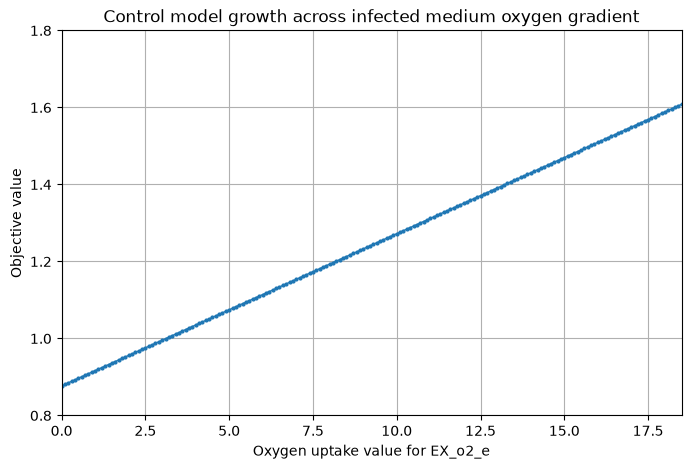

In [23]:
# Plot the results and label failed/no growth runs in red
# try extending oxygen to 100 to see if it's still linear


import matplotlib.pyplot as plt

plot_df = infected_o2_plot_df.sort_values("oxygen")

# Assume failed or missing objective values mean no growth
zero_growth_df = plot_df[np.isclose(plot_df["objective_value"], 0.0)]

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df["oxygen"],
    plot_df["objective_value"],
    marker="o", # marker can be removed to make the line thinner
    linewidth=1,
    markersize=2, # can be removed
    label="Growth"
)

# Overlay red markers where growth is 0
plt.scatter(
    zero_growth_df["oxygen"],
    zero_growth_df["objective_value"],
    color="red",
    s=50,
    zorder=3,
    label="No growth")

plt.xlim(0, 18.5) # zoom in on oxygen values from 0 to 18.5
plt.ylim(0.8, 1.8) # zoom in on growth values in this range

plt.xlabel("Oxygen uptake value for EX_o2_e")
plt.ylabel("Objective value")
plt.title("Control model growth across infected medium oxygen gradient")

plt.grid(True)
plt.show()

### Scale-up the oxygen availibility sweep to all models and media conditions

In [24]:
# A dictionary of all original models
original_models = {
    "control": control_model,
    "stm1090": stm1090_model,
    "stm1585": stm1585_model,
    "stm2575": stm2575_model,
    "mixed_stm1090": mixed_stm1090_model,
    "mixed_stm1585": mixed_stm1585_model,
    "mixed_stm2575": mixed_stm2575_model,
}

In [62]:
# Make copies of each model for FBA analyses

fba_models = {
    model_name: model.copy()
    for model_name, model in original_models.items()
}

         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/bd/zvg2hfl13hs5_kdz07q5mm700000gn/T/tmp154mnppa.lp
Reading time = 0.01 seconds
: 1802 rows, 5090 columns, 19612 nonzeros
         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/bd/zvg2hfl13hs5_kdz07q5mm700000gn/T/tmprz9n44lq.lp
Reading time = 0.01 seconds
: 2947 rows, 6220 columns, 24174 nonzeros
         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/bd/zvg2hfl13hs5_kdz07q5mm700000gn/T/tmpled1zq6_.lp
Reading time = 0.01 seconds
: 3201 rows, 6460 columns, 25176 nonzeros
         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/bd/zvg2hfl13hs5_kdz07q5mm700000gn/T/tmp3_ft8mfc.lp
Reading time = 0.01 seconds
: 3949 rows, 7128 columns, 28088 nonzeros


In [26]:
# add the oxygen gradient step to so that it's all in one function. Then I can add an argument to change the oxygen step level. Name it "step_level".

def run_oxygen_sweep(medium_condition, model_name):
    """
    Run FBA across all oxygen levels for a selected medium condition and model.

    Parameters
    ----------
    medium_condition : str
        Medium condition name, such as "default", "infected", or "uninfected".

    model_name : str
        Model name, such as "control".

    Returns
    -------
    pandas.DataFrame
        Dataframe containing oxygen level, solver status, and objective value.
    """

    # Check that the requested medium condition exists
    if medium_condition not in oxygen_gradient_media:
        raise ValueError(f"{medium_condition} is not in oxygen_gradient_media.")

    # Check that the requested model exists
    if model_name not in fba_models:
        raise ValueError(f"{model_name} is not in fba_models.")

    # Get a copied model for this FBA sweep
    model = fba_models[model_name].copy()

    # Get the oxygen-gradient media for the selected condition
    media_by_o2 = oxygen_gradient_media[medium_condition]

    results = []

    for o2_value, medium in media_by_o2.items():

        try:
            with model:
                model.medium = medium
                solution = model.optimize()

                if solution.status == "optimal":
                    objective_value = solution.objective_value
                else:
                    objective_value = np.nan

                results.append({
                    "model": model_name,
                    "medium_condition": medium_condition,
                    "oxygen": o2_value,
                    "status": solution.status,
                    "objective_value": objective_value
                })

        except Exception as error:
            results.append({
                "model": model_name,
                "medium_condition": medium_condition,
                "oxygen": o2_value,
                "status": "failed",
                "objective_value": np.nan,
                "error": str(error)
            })

            continue

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values("oxygen").reset_index(drop=True)

    return results_df

In [63]:
# Test the function

#  Write test to compare to earlier results

infected_control_o2_results_df = run_oxygen_sweep("infected","control")

infected_control_o2_results_df

         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/bd/zvg2hfl13hs5_kdz07q5mm700000gn/T/tmpzdoqadt8.lp
Reading time = 0.01 seconds
: 1802 rows, 5090 columns, 19612 nonzeros


,model,medium_condition,oxygen,status,objective_value
0,control,infected,0.0,optimal,0.876923
1,control,infected,0.1,optimal,0.880876
2,control,infected,0.2,optimal,0.884829
3,control,infected,0.3,optimal,0.888782
4,control,infected,0.4,optimal,0.892735
...,...,...,...,...,...
181,control,infected,18.1,optimal,1.592415
182,control,infected,18.2,optimal,1.596368
183,control,infected,18.3,optimal,1.600321
184,control,infected,18.4,optimal,1.604274


In [28]:
# Control oxygen gradient results 

oxygen_sweep_control_results = {}

oxygen_sweep_control_results[("infected", "control")] = run_oxygen_sweep("infected", "control")
oxygen_sweep_control_results[("default", "control")] = run_oxygen_sweep("default", "control")
oxygen_sweep_control_results[("uninfected", "control")] = run_oxygen_sweep("uninfected", "control")

         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/bd/zvg2hfl13hs5_kdz07q5mm700000gn/T/tmptw9u8lim.lp
Reading time = 0.01 seconds
: 1802 rows, 5090 columns, 19612 nonzeros
         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/bd/zvg2hfl13hs5_kdz07q5mm700000gn/T/tmpztdzt7z3.lp
Reading time = 0.01 seconds
: 1802 rows, 5090 columns, 19612 nonzeros
         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/bd/zvg2hfl13hs5_kdz07q5mm700000gn/T/tmpwrvx3ghm.lp
Reading time = 0.01 seconds
: 1802 rows, 5090 columns, 19612 nonzeros


In [29]:
# STM1090 oxygen gradient results

oxygen_sweep_stm1090_results = {}

oxygen_sweep_stm1090_results[("infected", "stm1090")] = run_oxygen_sweep("infected", "stm1090")
oxygen_sweep_stm1090_results[("default", "stm1090")] = run_oxygen_sweep("default", "stm1090")
oxygen_sweep_stm1090_results[("uninfected", "stm1090")] = run_oxygen_sweep("uninfected", "stm1090")

         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/bd/zvg2hfl13hs5_kdz07q5mm700000gn/T/tmpoa4pj4ay.lp
Reading time = 0.01 seconds
: 2947 rows, 6220 columns, 24174 nonzeros
         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/bd/zvg2hfl13hs5_kdz07q5mm700000gn/T/tmpt3_cjdsp.lp
Reading time = 0.01 seconds
: 2947 rows, 6220 columns, 24174 nonzeros


/Users/gina/miniforge3/envs/localgems/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/gina/miniforge3/envs/localgems/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/gina/miniforge3/envs/localgems/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/gina/miniforge3/envs/localgems/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/gina/miniforge3/envs/localgems/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/gina/miniforge3/envs/localgems/lib/python3.

         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/bd/zvg2hfl13hs5_kdz07q5mm700000gn/T/tmpi660c8qb.lp
Reading time = 0.01 seconds
: 2947 rows, 6220 columns, 24174 nonzeros


In [31]:
# STM1585 oxygen gradient results

oxygen_sweep_stm1585_results = {}

oxygen_sweep_stm1585_results[("infected", "stm1585")] = run_oxygen_sweep("infected", "stm1585")
oxygen_sweep_stm1585_results[("default", "stm1585")] = run_oxygen_sweep("default", "stm1585")
oxygen_sweep_stm1585_results[("uninfected", "stm1585")] = run_oxygen_sweep("uninfected", "stm1585")

         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/bd/zvg2hfl13hs5_kdz07q5mm700000gn/T/tmpbo7r_756.lp
Reading time = 0.01 seconds
: 3201 rows, 6460 columns, 25176 nonzeros

Interrupt request received
         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/bd/zvg2hfl13hs5_kdz07q5mm700000gn/T/tmpz1ofu9rq.lp
Reading time = 0.01 seconds
: 3201 rows, 6460 columns, 25176 nonzeros


/Users/gina/miniforge3/envs/localgems/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/gina/miniforge3/envs/localgems/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/gina/miniforge3/envs/localgems/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/gina/miniforge3/envs/localgems/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/gina/miniforge3/envs/localgems/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/gina/miniforge3/envs/localgems/lib/python3.

         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/bd/zvg2hfl13hs5_kdz07q5mm700000gn/T/tmpjvwmy8kj.lp
Reading time = 0.01 seconds
: 3201 rows, 6460 columns, 25176 nonzeros


In [ ]:
# STM2575 oxygen gradient results

oxygen_sweep_stm2575_results = {}

oxygen_sweep_stm2575_results[("infected", "stm2575")] = run_oxygen_sweep("infected", "stm2575")
oxygen_sweep_stm2575_results[("default", "stm2575")] = run_oxygen_sweep("default", "stm2575")
oxygen_sweep_stm2575_results[("uninfected", "stm2575")] = run_oxygen_sweep("uninfected", "stm2575")

In [32]:
# Mixed STM1090 oxygen gradient results

oxygen_sweep_mixed_stm1090_results = {}

oxygen_sweep_mixed_stm1090_results[("infected", "mixed_stm1090")] = run_oxygen_sweep("infected", "mixed_stm1090")
oxygen_sweep_mixed_stm1090_results[("default", "mixed_stm1090")] = run_oxygen_sweep("default", "mixed_stm1090")
oxygen_sweep_mixed_stm1090_results[("uninfected", "mixed_stm1090")] = run_oxygen_sweep("uninfected", "mixed_stm1090")

In [ ]:
# Mixed STM1585 oxygen gradient results

oxygen_sweep_mixed_stm1585_results = {}

oxygen_sweep_mixed_stm1585_results[("infected", "mixed_stm1585")] = run_oxygen_sweep("infected", "mixed_stm1585")
oxygen_sweep_mixed_stm1585_results[("default", "mixed_stm1585")] = run_oxygen_sweep("default", "mixed_stm1585")
oxygen_sweep_mixed_stm1585_results[("uninfected", "mixed_stm1585")] = run_oxygen_sweep("uninfected", "mixed_stm1585")

In [ ]:
# Mixed STM2575 oxygen gradient results

oxygen_sweep_mixed_stm2575_results = {}

oxygen_sweep_mixed_stm2575_results[("infected", "mixed_stm2575")] = run_oxygen_sweep("infected", "mixed_stm2575")
oxygen_sweep_mixed_stm2575_results[("default", "mixed_stm2575")] = run_oxygen_sweep("default", "mixed_stm2575")
oxygen_sweep_mixed_stm2575_results[("uninfected", "mixed_stm2575")] = run_oxygen_sweep("uninfected", "mixed_stm2575")

This is an alternative approach that could be useful for a function or a script: 

```
oxygen_sweep_results = {}

for medium_condition in oxygen_gradient_media.keys():
    for model_name in fba_models.keys():

        result_df = run_oxygen_sweep(
            medium_condition=medium_condition,
            model_name=model_name
        )

        oxygen_sweep_results[(medium_condition, model_name)] = result_df
```

## Gene Knockout Analysis

**Note** Do this later. 

## Generate plots and tables for meeting

### Make csv and image of the default medium

In [66]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
from IPython.display import FileLink, display

# sort by reactions with different values 


# -----------------------------
# 1. Create output directory
# -----------------------------
outdir = Path("062226_labmeeting")
outdir.mkdir(exist_ok=True)

# -----------------------------
# 2. Handle possible variable names
# -----------------------------
if "infection_medium" in globals():
    infection_medium_to_use = infection_medium
elif "infected_medium" in globals():
    infection_medium_to_use = infected_medium
else:
    raise NameError("Could not find infection_medium or infected_medium.")

required_objects = ["default_medium", "uninfected_medium", "control_model"]
missing = [obj for obj in required_objects if obj not in globals()]

if missing:
    raise NameError(f"Missing required object(s): {missing}")

media_dicts = {
    "Default": default_medium,
    "Uninfected": uninfected_medium,
    "Infection": infection_medium_to_use,
}

# -----------------------------
# 3. Build comparison table
# -----------------------------
all_rxns = sorted(set().union(*[set(medium.keys()) for medium in media_dicts.values()]))

rows = []

for rxn_id in all_rxns:
    try:
        rxn = control_model.reactions.get_by_id(rxn_id)
        met = list(rxn.metabolites)[0]
        met_id = met.id
        met_name = met.name
    except KeyError:
        met_id = "not found"
        met_name = "not found"
    
    rows.append({
        "Exchange reaction": rxn_id,
        "Metabolite ID": met_id,
        "Metabolite": met_name,
        "Default uptake": media_dicts["Default"].get(rxn_id, 0.0),
        "Uninfected uptake": media_dicts["Uninfected"].get(rxn_id, 0.0),
        "Infection uptake": media_dicts["Infection"].get(rxn_id, 0.0),
    })

medium_df = pd.DataFrame(rows)

# Put changed reactions first
uptake_cols = ["Default uptake", "Uninfected uptake", "Infection uptake"]
medium_df["_changed"] = medium_df[uptake_cols].nunique(axis=1) > 1

medium_df = (
    medium_df
    .sort_values(by=["_changed", "Exchange reaction"], ascending=[False, True])
    .drop(columns="_changed")
    .reset_index(drop=True)
)

# -----------------------------
# 4. Save CSV
# -----------------------------
csv_path = outdir / "medium_comparison_default_uninfected_infection.csv"
medium_df.to_csv(csv_path, index=False)

print(f"Saved CSV to: {csv_path}")
display(FileLink(str(csv_path)))

medium_df

Saved CSV to: 062226_labmeeting/medium_comparison_default_uninfected_infection.csv


/Users/gina/Documents/2026_GEMs/stm_model_test/062226_labmeeting/medium_comparison_default_uninfected_infection.csv

,Exchange reaction,Metabolite ID,Metabolite,Default uptake,Uninfected uptake,Infection uptake
0,EX_12ppd__R_e,12ppd__R_e,"(R)-Propane-1,2-diol",0.00,0.10,0.10
1,EX_12ppd__S_e,12ppd__S_e,"(S)-Propane-1,2-diol",0.00,0.10,0.10
2,EX_ac_e,ac_e,Acetate,0.00,50.00,50.00
3,EX_arab__L_e,arab__L_e,L-Arabinose,0.00,13.30,13.30
4,EX_asp__L_e,asp__L_e,L-Aspartate,0.00,5.00,5.00
5,EX_but_e,but_e,Butyrate (n-C4:0),0.00,10.00,10.00
6,EX_etha_e,etha_e,Ethanolamine,0.00,1.00,1.00
7,EX_for_e,for_e,Formate,0.00,4.00,4.00
8,EX_galct__D_e,galct__D_e,D-Galactarate,0.00,10.00,10.00
9,EX_glc__D_e,glc__D_e,D-Glucose,5.00,0.00,0.00


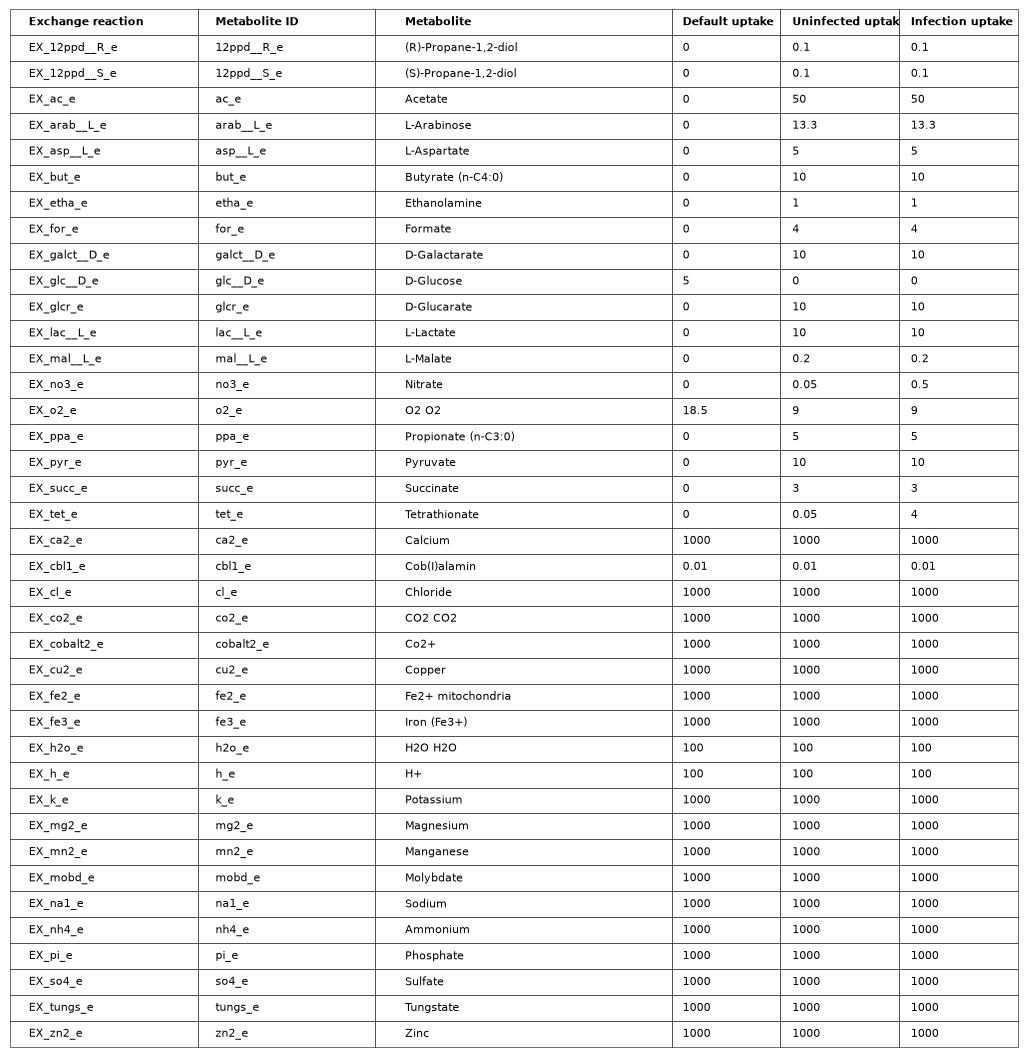

Saved image to: 062226_labmeeting/medium_comparison_default_uninfected_infection.png


/Users/gina/Documents/2026_GEMs/stm_model_test/062226_labmeeting/medium_comparison_default_uninfected_infection.png

In [67]:
# -----------------------------
# 5. Make minimally formatted table image
# -----------------------------
plot_df = medium_df.copy()

# Wrap long metabolite names so the table stays readable
plot_df["Metabolite"] = plot_df["Metabolite"].apply(
    lambda x: "\n".join(textwrap.wrap(str(x), width=26))
)

# Format uptake values
for col in ["Default uptake", "Uninfected uptake", "Infection uptake"]:
    plot_df[col] = plot_df[col].map(lambda x: f"{x:g}")

n_rows = len(plot_df)

# Adjust figure height based on number of rows
fig_height = max(4, 0.32 * n_rows + 1)
fig, ax = plt.subplots(figsize=(13, fig_height))
ax.axis("off")

table = ax.table(
    cellText=plot_df.values,
    colLabels=plot_df.columns,
    cellLoc="left",
    colLoc="left",
    loc="center",
    bbox=[0, 0, 1, 1]
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.25)

# Minimal formatting: bold header only
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
    cell.set_linewidth(0.4)

# Column widths
col_widths = {
    0: 0.19,  # Exchange reaction
    1: 0.18,  # Metabolite ID
    2: 0.30,  # Metabolite
    3: 0.11,  # Default uptake
    4: 0.12,  # Uninfected uptake
    5: 0.12,  # Infection uptake
}

for col, width in col_widths.items():
    for row in range(n_rows + 1):
        table[(row, col)].set_width(width)

png_path = outdir / "medium_comparison_default_uninfected_infection.png"

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1
)

plt.show()

print(f"Saved image to: {png_path}")
display(FileLink(str(png_path)))